In [275]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [276]:
df = pd.read_csv('titanic.csv').copy()
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [277]:
df.drop(columns=['PassengerId', 'Name', 'SibSp','Parch','Ticket','Fare','Cabin', 'Survived'],axis=1 , inplace=True)
df

,Pclass,Sex,Age,Embarked
0,3,male,34.5,Q
1,3,female,47.0,S
2,2,male,62.0,Q
3,3,male,27.0,S
4,3,female,22.0,S
...,...,...,...,...
413,3,male,NaN,S
414,1,female,39.0,C
415,3,male,38.5,S
416,3,male,NaN,S


In [278]:
# Fill missing Age based on the median of their Pclass and Sex group
df['Age'] = df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'))
df

,Pclass,Sex,Age,Embarked
0,3,male,34.5,Q
1,3,female,47.0,S
2,2,male,62.0,Q
3,3,male,27.0,S
4,3,female,22.0,S
...,...,...,...,...
413,3,male,24.0,S
414,1,female,39.0,C
415,3,male,38.5,S
416,3,male,24.0,S


In [279]:
df['Sex'].replace({
    'female':1,
    'male':0
},inplace=True)

/var/folders/jf/8ft3n5497pn97syqdww0k3gr0000gn/T/ipykernel_1129/1872776656.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sex'].replace({
/var/folders/jf/8ft3n5497pn97syqdww0k3gr0000gn/T/ipykernel_1129/1872776656.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex'].replace({


In [280]:
df

,Pclass,Sex,Age,Embarked
0,3,0,34.5,Q
1,3,1,47.0,S
2,2,0,62.0,Q
3,3,0,27.0,S
4,3,1,22.0,S
...,...,...,...,...
413,3,0,24.0,S
414,1,1,39.0,C
415,3,0,38.5,S
416,3,0,24.0,S


In the Titanic dataset, the Embarked feature represents the Port of Departure—essentially, the city where the passenger boarded the ship.

The column contains three unique letter codes, which correspond to the three stops the Titanic made before heading across the Atlantic:

The Three Ports
Code	City	Country
C	Cherbourg	France
Q	Queenstown	Ireland (now Cobh)
S	Southampton	United Kingdom

# Now we are going to replace the value with numbers 
# The Three Ports
Code	City	Country                        encoded number
C	Cherbourg	France                              1
Q	Queenstown	Ireland (now Cobh)                  2   
S	Southampton	United Kingdom                      3


In [281]:
df['Embarked'].replace({
    'C' : 1,
    'Q' : 2,
    'S' : 3
},inplace=True)

/var/folders/jf/8ft3n5497pn97syqdww0k3gr0000gn/T/ipykernel_1129/1049314396.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].replace({
/var/folders/jf/8ft3n5497pn97syqdww0k3gr0000gn/T/ipykernel_1129/1049314396.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Embarked'].replac

In [282]:
df

,Pclass,Sex,Age,Embarked
0,3,0,34.5,2
1,3,1,47.0,3
2,2,0,62.0,2
3,3,0,27.0,3
4,3,1,22.0,3
...,...,...,...,...
413,3,0,24.0,3
414,1,1,39.0,1
415,3,0,38.5,3
416,3,0,24.0,3


In [283]:
X = df[['Pclass', 'Age', 'Embarked']]
y = df[['Sex']]

In [284]:
X

,Pclass,Age,Embarked
0,3,34.5,2
1,3,47.0,3
2,2,62.0,2
3,3,27.0,3
4,3,22.0,3
...,...,...,...
413,3,24.0,3
414,1,39.0,1
415,3,38.5,3
416,3,24.0,3


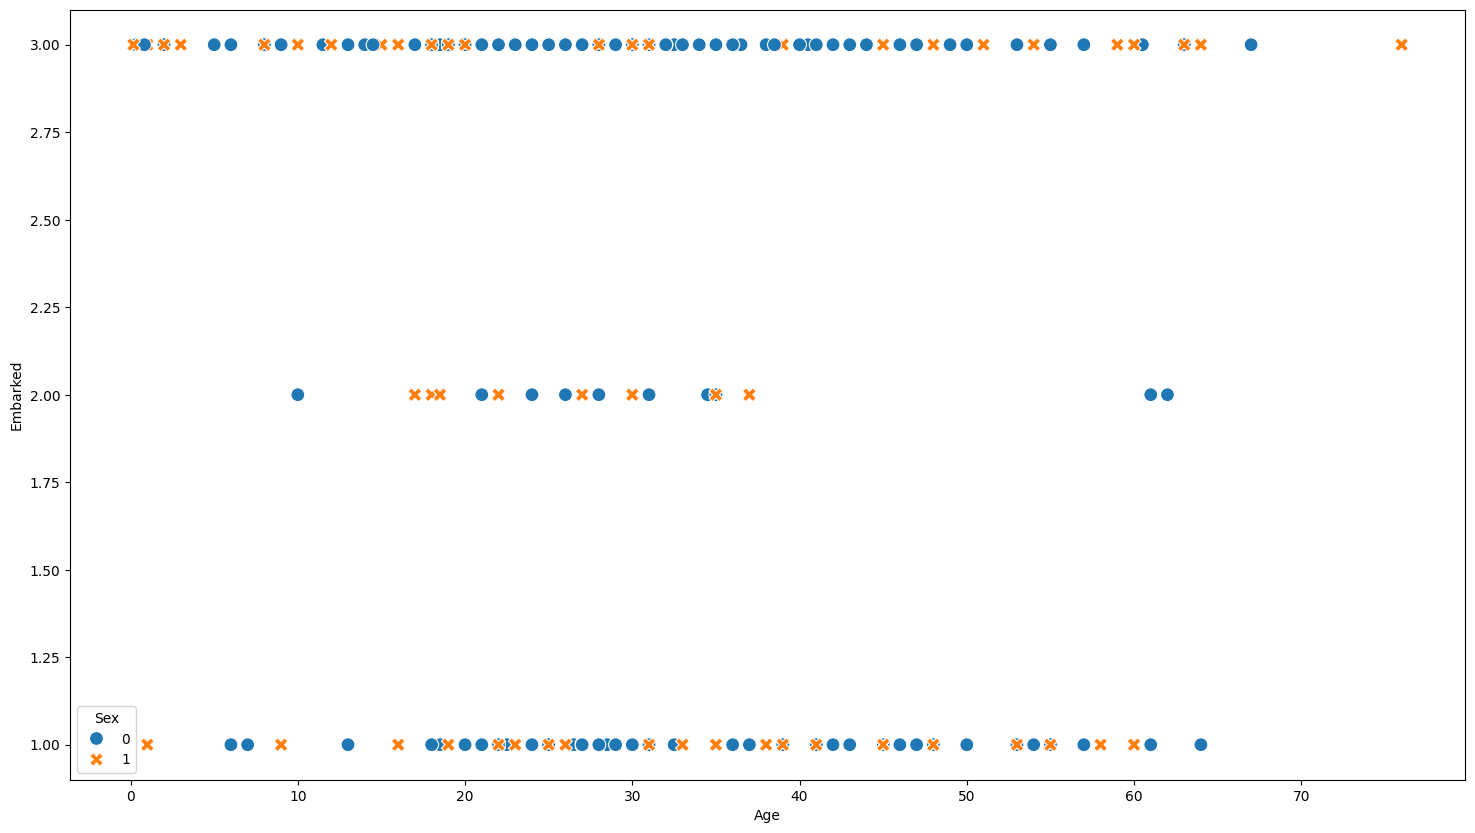

In [285]:
plt.figure(figsize=(18, 10))
sns.scatterplot(
    x=X['Age'],
    y=X['Embarked'],
    hue='Sex',
    style='Sex',
    data=df,
    s=100
)
plt.show()


In [286]:
X.shape

(418, 3)

In [287]:
y.shape

(418, 1)

In [288]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()

In [289]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [290]:
X_train.shape

(334, 3)

In [291]:
X_test.shape

(84, 3)

In [292]:
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [293]:
y_pred = clf.predict(X_test)

In [294]:
from sklearn.metrics import accuracy_score,classification_report
print(f"The accuracy of the model without hyperparameter tuning is : {accuracy_score(y_test, y_pred)}")


The accuracy of the model without hyperparameter tuning is : 0.6547619047619048


In [295]:
print(f"The accuracy of the model without hyperparameter tuning is : {classification_report(y_test, y_pred)}")


The accuracy of the model without hyperparameter tuning is :               precision    recall  f1-score   support

           0       0.67      0.82      0.74        50
           1       0.61      0.41      0.49        34

    accuracy                           0.65        84
   macro avg       0.64      0.62      0.61        84
weighted avg       0.65      0.65      0.64        84



[Text(0.2988119834710744, 0.9705882352941176, 'x[1] <= 23.5\ngini = 0.457\nsamples = 334\nvalue = [216, 118]'),
 Text(0.14015151515151514, 0.9117647058823529, 'x[1] <= 21.5\ngini = 0.5\nsamples = 112\nvalue = [56, 56]'),
 Text(0.21948174931129477, 0.9411764705882353, 'True  '),
 Text(0.046143250688705235, 0.8529411764705882, 'x[1] <= 0.875\ngini = 0.469\nsamples = 72\nvalue = [45, 27]'),
 Text(0.03512396694214876, 0.7941176470588235, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.05716253443526171, 0.7941176470588235, 'x[1] <= 1.5\ngini = 0.476\nsamples = 69\nvalue = [42, 27]'),
 Text(0.046143250688705235, 0.7352941176470589, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.06818181818181818, 0.7352941176470589, 'x[1] <= 7.5\ngini = 0.457\nsamples = 65\nvalue = [42, 23]'),
 Text(0.03305785123966942, 0.6764705882352942, 'x[1] <= 3.5\ngini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.02203856749311295, 0.6176470588235294, 'x[0] <= 2.5\ngini = 0.5\nsamples = 2\nvalue = [1, 1]')

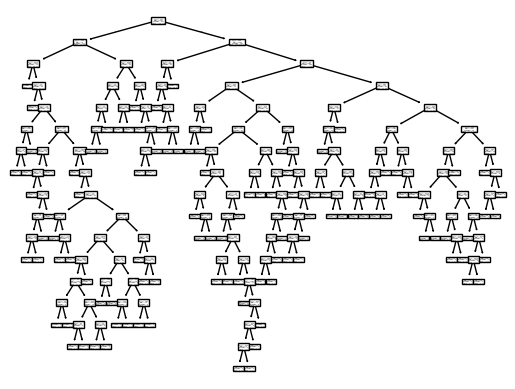

In [296]:
from sklearn.tree import plot_tree
plot_tree(clf)

# Now using Hyperparameter tuning ! using GridSearchCV

In [297]:
from sklearn.model_selection import GridSearchCV

In [298]:
param_dict = {
    'max_depth' : [1, 2, 3, 4, 5, None],
    'criterion' :['gini', 'entropy']
}

In [299]:
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param_dict,
    cv=5,
    n_jobs=-1 #NOTE: using all cores of my CPU 
)

In [300]:
grid.fit(X_train,y_train)
print(f"Best parameters needs to be selected is : {grid.best_params_}")
print(f"The accuracy of best tuned parameters are : {grid.best_score_}")

Best parameters needs to be selected is : {'criterion': 'gini', 'max_depth': 3}
The accuracy of best tuned parameters are : 0.6885572139303482


In [301]:
y_pred_tuned = grid.predict(X_test)
print(f"The classification report with hyperparameter tuning is : {classification_report(y_test, y_pred_tuned)}")


The classification report with hyperparameter tuning is :               precision    recall  f1-score   support

           0       0.65      0.98      0.78        50
           1       0.89      0.24      0.37        34

    accuracy                           0.68        84
   macro avg       0.77      0.61      0.58        84
weighted avg       0.75      0.68      0.62        84

